In [ ]:
!pip install rembg opencv-contrib-python-headless pillow onnxruntime

INFO: pip is looking at multiple versions of numba to determine which version is compatible with other requirements. This could take a while.
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 62.5/62.5 kB 3.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 69.5/69.5 MB 10.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 6.9/6.9 MB 86.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 23.1/23.1 MB 59.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 16.7/16.7 MB 65.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 54.9/54.9 kB 2.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 13.7/13.7 MB 70.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.9/3.9 MB 67.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 59.9/59.9 MB 10.0 MB/s eta 0:00:00
  Attempting uninstall: pillow
    Found existing installation: pillow 11.3.0
    Uninstalling pillow-11.3.0:
      Successfully uninstalled pillow-11.3.

In [ ]:
from rembg import remove, new_session
from PIL import Image, ImageEnhance, ImageFilter, ImageDraw, ImageOps
import numpy as np
import cv2
import matplotlib.pyplot as plt
from IPython.display import Javascript, display
from google.colab.output import eval_js
from google.colab import files
from base64 import b64decode

In [ ]:
session = new_session("isnet-general-use")
print("Segmentation model loaded.")

  0%|                                               | 0.00/179M [00:00<?, ?B/s]

Segmentation model loaded.


In [ ]:
!wget -q https://raw.githubusercontent.com/Saafke/FSRCNN_Tensorflow/master/models/FSRCNN_x4.pb -O FSRCNN_x4.pb

sr = cv2.dnn_superres.DnnSuperResImpl_create()
sr.readModel("FSRCNN_x4.pb")
sr.setModel("fsrcnn", 4)
print("Super-resolution model loaded.")

Super-resolution model loaded.


In [ ]:
CAMERA_JS = """
async function takePhoto() {
  const div = document.createElement('div');
  const video = document.createElement('video');
  const button = document.createElement('button');
  button.textContent = '📸 Capture Photo';
  button.style.cssText = 'font-size:18px; padding:10px 20px; margin-top:10px; cursor:pointer;';
  video.style.width = '100%';
  video.style.maxWidth = '600px';
  div.appendChild(video);
  div.appendChild(document.createElement('br'));
  div.appendChild(button);
  document.body.appendChild(div);

  const stream = await navigator.mediaDevices.getUserMedia({
    video: { width: { ideal: 1920 }, height: { ideal: 1080 } }
  });
  video.srcObject = stream;
  await video.play();
  await new Promise(resolve => button.onclick = resolve);

  const canvas = document.createElement('canvas');
  canvas.width = video.videoWidth;
  canvas.height = video.videoHeight;
  canvas.getContext('2d').drawImage(video, 0, 0);
  stream.getTracks().forEach(t => t.stop());
  div.remove();
  return canvas.toDataURL('image/jpeg', 0.98);
}
"""

def capture_photo(filename="captured.jpg"):
    display(Javascript(CAMERA_JS))
    data_url = eval_js('takePhoto()')
    binary = b64decode(data_url.split(',')[1])
    with open(filename, "wb") as f:
        f.write(binary)
    print(f"Photo captured: {filename} ({len(binary)/1024:.1f} KB)")
    return filename

In [ ]:
def upload_photo():
    uploaded = files.upload()
    if not uploaded:
        print("No file uploaded.")
        return None
    filename = list(uploaded.keys())[0]
    print(f"Uploaded: {filename}")
    return filename

In [ ]:
def clean_mask(raw_alpha, feather=3):
    mask_np = np.array(raw_alpha).astype(np.uint8)

    # Low threshold ONLY to find which connected blob is the main object —
    # low value so thin, faint structures (trunks, horns) still count as "present"
    _, presence = cv2.threshold(mask_np, 30, 255, cv2.THRESH_BINARY)

    num_labels, labels, stats, _ = cv2.connectedComponentsWithStats(presence, connectivity=8)
    if num_labels > 1:
        largest_label = 1 + np.argmax(stats[1:, cv2.CC_STAT_AREA])
        keep = (labels == largest_label).astype(np.uint8)
    else:
        keep = np.ones_like(mask_np)

    # Grow the keep-region slightly so we don't clip soft/anti-aliased edges
    kernel = np.ones((7, 7), np.uint8)
    keep = cv2.dilate(keep, kernel)

    # Preserve the ORIGINAL soft alpha values inside the kept region —
    # this is what saves thin, low-confidence parts instead of hard-cutting them
    cleaned = mask_np * keep
    cleaned = cv2.GaussianBlur(cleaned, (feather, feather), 0)

    return Image.fromarray(cleaned)

In [ ]:
def create_soft_shadow(mask, size, blur_radius=25, opacity=90):
    shadow = Image.new("L", size, 0)
    mask_np = np.array(mask)
    ys, xs = np.where(mask_np > 10)
    if len(xs) == 0:
        return shadow
    x_min, x_max, y_max = xs.min(), xs.max(), ys.max()
    shadow_w = int((x_max - x_min) * 0.8)
    shadow_h = int(shadow_w * 0.25)
    cx = (x_min + x_max) // 2
    draw = ImageDraw.Draw(shadow)
    draw.ellipse([cx - shadow_w//2, y_max - shadow_h//2, cx + shadow_w//2, y_max + shadow_h//2], fill=opacity)
    return shadow.filter(ImageFilter.GaussianBlur(blur_radius))

def studio_background(size, color=(250, 250, 250)):
    w, h = size
    bg = np.zeros((h, w, 3), dtype=np.uint8)
    for y in range(h):
        factor = 1 - (y / h) * 0.06
        bg[y, :] = [int(c * factor) for c in color]
    return Image.fromarray(bg)

In [ ]:
def gentle_enhance(pil_img):
    img = ImageOps.autocontrast(pil_img, cutoff=1)
    img = ImageEnhance.Color(img).enhance(1.08)
    img = ImageEnhance.Brightness(img).enhance(1.03)
    return img

In [ ]:
def enhance_product_image(input_path, output_path="enhanced.jpg", canvas_size=(1400, 1400)):
    original = Image.open(input_path).convert("RGB")

    no_bg = remove(original, session=session)
    alpha_mask = clean_mask(no_bg.split()[3])

    mask_np = np.array(alpha_mask)
    ys, xs = np.where(mask_np > 30)
    if len(xs) == 0:
        print("⚠️ No object detected.")
        return original, original

    x_min, x_max, y_min, y_max = xs.min(), xs.max(), ys.min(), ys.max()
    pad = int((x_max - x_min) * 0.08)
    x_min, x_max = max(0, x_min-pad), min(original.width, x_max+pad)
    y_min, y_max = max(0, y_min-pad), min(original.height, y_max+pad)

    cropped_original = original.crop((x_min, y_min, x_max, y_max))
    cropped_mask = alpha_mask.crop((x_min, y_min, x_max, y_max))

    corrected = gentle_enhance(cropped_original)

    hd_product = Image.fromarray(cv2.cvtColor(
        sr.upsample(cv2.cvtColor(np.array(corrected), cv2.COLOR_RGB2BGR)),
        cv2.COLOR_BGR2RGB))
    hd_mask = cropped_mask.resize(hd_product.size, Image.LANCZOS)

    scale = min((canvas_size[0]*0.7)/hd_product.width, (canvas_size[1]*0.7)/hd_product.height)
    new_size = (int(hd_product.width*scale), int(hd_product.height*scale))
    resized_product = hd_product.resize(new_size, Image.LANCZOS)
    resized_mask = hd_mask.resize(new_size, Image.LANCZOS)

    bg = studio_background(canvas_size)
    px = (canvas_size[0]-new_size[0])//2
    py = int((canvas_size[1]-new_size[1])*0.62)

    full_mask = Image.new("L", canvas_size, 0)
    full_mask.paste(resized_mask, (px, py))
    shadow = create_soft_shadow(full_mask, canvas_size)
    bg.paste(Image.new("RGB", canvas_size, (0,0,0)), (0,0), shadow)
    bg.paste(resized_product, (px, py), resized_mask)

    final = ImageEnhance.Sharpness(bg).enhance(1.3)
    final.save(output_path, quality=95)
    return original, final

Type 'camera' or 'upload': upload


Saving WhatsApp Image 2026-09-07 at 1.51.16 AM.jpeg to WhatsApp Image 2026-09-07 at 1.51.16 AM.jpeg
Uploaded: WhatsApp Image 2026-09-07 at 1.51.16 AM.jpeg


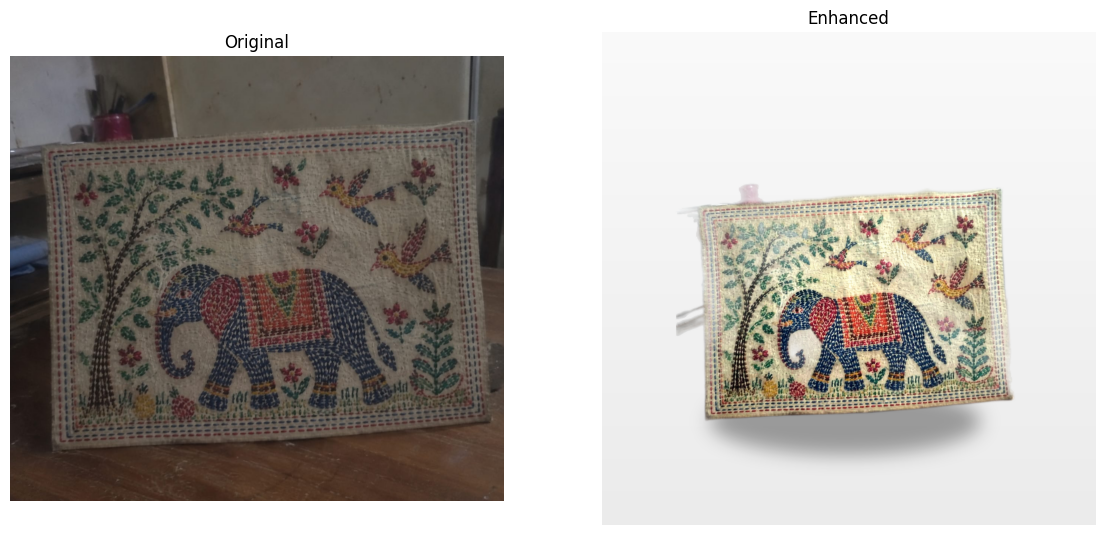

In [ ]:
mode = input("Type 'camera' or 'upload': ").strip().lower()
photo_path = capture_photo() if mode == "camera" else upload_photo()

original, enhanced = enhance_product_image(photo_path)

fig, axes = plt.subplots(1, 2, figsize=(14, 7))
axes[0].imshow(original); axes[0].set_title("Original"); axes[0].axis("off")
axes[1].imshow(enhanced); axes[1].set_title("Enhanced"); axes[1].axis("off")
plt.show()

In [ ]:
files.download("enhanced.jpg")